# Viral sequence analysis from czid data
This notebook was created to analyze [CZID](https://czid.org) data from the same samples that will be analyzed through our shell scripts. The main idea behind this is to corroborate the results given by both methods and determine the viability of the designed pipeline. 

## Libraries.

In [ ]:
# Libraries for data manipulation and visualization

import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler




## Data load.
All sample information was downloaded.

In [3]:
base_path = Path.cwd().parents[1]

file_paths = {
    "PM3183": base_path / 'docs/czid_sequence_reports/PM3183_S6_923339_taxon_report.csv',
    "PM3051": base_path / 'docs/czid_sequence_reports/PM3051_S4_923337_taxon_report.csv',
    "PM3050": base_path / 'docs/czid_sequence_reports/PM3050_S3_929426_taxon_report.csv',
    "PM3153": base_path / 'docs/czid_sequence_reports/PM3153_S5_923338_taxon_report.csv',
    "PM2622": base_path / 'docs/czid_sequence_reports/PM2622_S32_923335_taxon_report.csv',
    "PM2616": base_path / 'docs/czid_sequence_reports/PM2616_S22_923334_taxon_report.csv',
    "PM2601": base_path / 'docs/czid_sequence_reports/PM2601_S14_923333_taxon_report.csv',
    "PM2577": base_path / 'docs/czid_sequence_reports/PM2577_S13_923332_taxon_report.csv',
    "PM2539": base_path / 'docs/czid_sequence_reports/PM2539_S23_923331_taxon_report.csv',
    "PM2528": base_path / 'docs/czid_sequence_reports/PM2528_S2_923330_taxon_report.csv',
    "PM2524": base_path / 'docs/czid_sequence_reports/PM2524_S24_923329_taxon_report.csv',
    "PM2494": base_path / 'docs/czid_sequence_reports/PM2494_S26_923327_taxon_report.csv',
    "PM2469": base_path / 'docs/czid_sequence_reports/PM2469_S1_923325_taxon_report.csv',
    "PM2497": base_path / 'docs/czid_sequence_reports/PM2497_S12_929424_taxon_report.csv',
    "PM2486": base_path / 'docs/czid_sequence_reports/PM2486_S27_929425_taxon_report.csv'
}

samples = list(file_paths.keys())


    

## Dataframe modification.

In [4]:
# Dataframe modification and concatenation.

df_samples= []

for i in samples:
    # File read for each sample.
    file = file_paths[i]
    print(f"Sample: {i}")
    df=pd.read_csv(file)

    # Since the taxon category column is of our interest, we can filter every dataframe by the value of 'viruses' in the taxon category column to keep only the rows that have this value. 
    row_del = df['category'] == 'viruses' # If the taxId column has the value 'viruses' then we keep that row, otherwise we delete it.
    df = df[row_del].copy()

    # Add sample name to the dataframe.
    df['sample_name'] = i
    df_samples.append(df)


# Dataframe concatenation.
df_samples = pd.concat(df_samples, ignore_index=True)

display(df_samples)

Sample: PM3183
Sample: PM3051
Sample: PM3050
Sample: PM3153
Sample: PM2622
Sample: PM2616
Sample: PM2601
Sample: PM2577
Sample: PM2539
Sample: PM2528
Sample: PM2524
Sample: PM2494
Sample: PM2469
Sample: PM2497
Sample: PM2486


,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,agg_score,max_z_score,nt_z_score,...,nr_percent_identity,nr_alignment_length,nr_e_value,nr_bg_mean,nr_bg_stdev,nr_bg_mean_mass_normalized,nr_bg_stdev_mass_normalized,species_tax_ids,known_pathogen,sample_name
0,2842620,2,2842620,Culicidavirus,NaN,viruses,False,NaN,NaN,NaN,...,72.0000,25.0000,10^-5.79588,NaN,NaN,NaN,NaN,[2844040],0,PM3183
1,2844040,1,2842620,Culicidavirus quitotaense,NaN,viruses,False,NaN,NaN,NaN,...,72.0000,25.0000,10^-5.79588,NaN,NaN,NaN,NaN,NaN,0,PM3183
2,1884455,2,1884455,Anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,83.6500,24.5000,10^-5.18245,NaN,NaN,NaN,NaN,[2980617],0,PM3183
3,2980617,1,1884455,Joensuu anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,83.6500,24.5000,10^-5.18245,NaN,NaN,NaN,NaN,NaN,0,PM3183
4,1307798,2,1307798,Negevirus,NaN,viruses,False,NaN,NaN,NaN,...,97.2333,24.0000,10^-6.41519,NaN,NaN,NaN,NaN,[2651953],0,PM3183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581,-201980417,2,-201980417,non-genus-specific reads in family Phasmaviridae,NaN,viruses,False,NaN,NaN,NaN,...,96.9000,32.0000,10^-11.3565,NaN,NaN,NaN,NaN,[2778219],0,PM2486
1582,2778219,1,-201980417,Aedes phasmavirus,NaN,viruses,False,NaN,NaN,NaN,...,96.9000,32.0000,10^-11.3565,NaN,NaN,NaN,NaN,NaN,0,PM2486
1583,-202501952,2,-202501952,non-genus-specific reads in family Chuviridae,NaN,viruses,False,NaN,NaN,NaN,...,66.1055,72.7561,10^-23.4954,NaN,NaN,NaN,NaN,"[2789882, 2789881]",0,PM2486
1584,2789882,1,-202501952,Gurupi chuvirus-like 2,NaN,viruses,False,NaN,NaN,NaN,...,88.1580,76.0000,10^-44.8962,NaN,NaN,NaN,NaN,NaN,0,PM2486


In [5]:
# Dataframe cleaning and manipulation.
df_samples = df_samples.drop(columns= ['agg_score',	'max_z_score',	'nt_z_score', 'nt_bg_mean',	'nt_bg_stdev',	
                                       'nt_bg_mean_mass_normalized',	'nt_bg_stdev_mass_normalized',	'nr_z_score', 
                                       'nr_bg_mean',	'nr_bg_stdev',	'nr_bg_mean_mass_normalized',	'nr_bg_stdev_mass_normalized'])
display(df_samples)

,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,nt_rpm,nt_count,nt_contigs,...,nr_rpm,nr_count,nr_contigs,nr_contig_r,nr_percent_identity,nr_alignment_length,nr_e_value,species_tax_ids,known_pathogen,sample_name
0,2842620,2,2842620,Culicidavirus,NaN,viruses,False,NaN,NaN,NaN,...,0.119115,1.0,NaN,NaN,72.0000,25.0000,10^-5.79588,[2844040],0,PM3183
1,2844040,1,2842620,Culicidavirus quitotaense,NaN,viruses,False,NaN,NaN,NaN,...,0.119115,1.0,NaN,NaN,72.0000,25.0000,10^-5.79588,NaN,0,PM3183
2,1884455,2,1884455,Anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,0.238229,2.0,NaN,NaN,83.6500,24.5000,10^-5.18245,[2980617],0,PM3183
3,2980617,1,1884455,Joensuu anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,0.238229,2.0,NaN,NaN,83.6500,24.5000,10^-5.18245,NaN,0,PM3183
4,1307798,2,1307798,Negevirus,NaN,viruses,False,0.238229,2.0,NaN,...,0.357344,3.0,NaN,NaN,97.2333,24.0000,10^-6.41519,[2651953],0,PM3183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581,-201980417,2,-201980417,non-genus-specific reads in family Phasmaviridae,NaN,viruses,False,NaN,NaN,NaN,...,0.102889,1.0,NaN,NaN,96.9000,32.0000,10^-11.3565,[2778219],0,PM2486
1582,2778219,1,-201980417,Aedes phasmavirus,NaN,viruses,False,NaN,NaN,NaN,...,0.102889,1.0,NaN,NaN,96.9000,32.0000,10^-11.3565,NaN,0,PM2486
1583,-202501952,2,-202501952,non-genus-specific reads in family Chuviridae,NaN,viruses,False,NaN,NaN,NaN,...,4.218464,41.0,NaN,NaN,66.1055,72.7561,10^-23.4954,"[2789882, 2789881]",0,PM2486
1584,2789882,1,-202501952,Gurupi chuvirus-like 2,NaN,viruses,False,NaN,NaN,NaN,...,0.411557,4.0,1.0,4.0,88.1580,76.0000,10^-44.8962,NaN,0,PM2486


In [6]:

# Metadata by sample. This includes sample name, locality, mosquito species, ecological classification
df_metadata = pd.read_csv(base_path / 'docs/czid_sequence_reports/sample_overviews.csv')

# Metadata cleaning and manipulation.

# Sample name modification to match sample names in the sequence report dataframe.
df_metadata["sample_name"] = df_metadata["sample_name"].str.replace(r"_S\d{1,2}", "", regex=True)

# Variable renaming.
df_metadata["state"] = df_metadata["collection_location"].str.strip()

# Column dropping.
df_metadata = df_metadata.drop(columns= ['upload_date', 'notes', 'insert_size_median',	'insert_size_mode',	'insert_size_median_absolute_deviation',	
                                         'insert_size_min',	'insert_size_max',	'insert_size_mean',	'insert_size_standard_deviation',	'insert_size_read_pairs', 'collection_location'])


# Sampling site
site = {
    "PM2469": "Nuevo_Conhuas",
    "PM2486": "Calkini",
    "PM2494": "Calkini",
    "PM2497": "Calkini",
    "PM2524": "Nuevo_Conhuas",
    "PM2528": "Nuevo_Conhuas",
    "PM2539": "Merida",
    "PM2577": "Nuevo_Conhuas",
    "PM2601": "San_Simon",
    "PM2616": "San_Simon",
    "PM2622": "San_Simon",
    "PM3050": "Palizada",
    "PM3051": "Palizada",
    "PM3153": "Caobas",
    "PM3183": "Caobas"
}

df_metadata["site"] = df_metadata["sample_name"].map(site)

# Sample ecological classification based on the locality of collection.
habitat = {
    "PM2469": "conservado",
    "PM2486": "diversificado",
    "PM2494": "diversificado",
    "PM2497": "diversificado",
    "PM2524": "conservado",
    "PM2528": "conservado",
    "PM2539": "urbano",
    "PM2577": "conservado",
    "PM2601": "conservado",
    "PM2616": "conservado",
    "PM2622": "conservado",
    "PM3050": "rural",
    "PM3051": "rural",
    "PM3153": "diversificado",
    "PM3183": "diversificado"
}

df_metadata["habitat"] = df_metadata["sample_name"].map(habitat)

# Mosquito species by sample
species = {
    "PM2469": "aedes_serratus",
    "PM2486": "aedes_taeniorhynchus",
    "PM2494": "aedes_taeniorhynchus",
    "PM2497": "aedes_taeniorhynchus",
    "PM2524": "aedes_taeniorhynchus",
    "PM2528": "aedes_serratus",
    "PM2539": "aedes_taeniorhynchus",
    "PM2577": "aedes_taeniorhynchus",
    "PM2601": "aedes_taeniorhynchus",
    "PM2616": "aedes_taeniorhynchus",
    "PM2622": "aedes_taeniorhynchus",
    "PM3050": "aedes_serratus",
    "PM3051": "aedes_serratus",
    "PM3153": "aedes_serratus",
    "PM3183": "aedes_serratus"
}

df_metadata["species"] = df_metadata["sample_name"].map(species)

display(df_metadata)

''

,sample_name,uploader,overall_job_status,runtime_seconds,total_reads,passed_filters,passed_filters_percent,host_organism,total_ercc_reads,subsampled_fraction,...,reads_after_hisat2_host_filtered,reads_after_czid_dedup,sample_type,nucleotide_type,collection_date,water_control,state,site,habitat,species
0,PM2469,Jorge Alberto Castro Rodríguez,COMPLETE,2696,8706270,829594,9.529,Mosquito,68.0,1.000000,...,1650712,667202,Whole Body,RNA,01/01/2024,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus
1,PM2494,Jorge Alberto Castro Rodríguez,COMPLETE,10911,58137502,2539988,4.369,Mosquito,1466.0,0.229556,...,11270008,8684188,Whole Body,RNA,01/01/2024,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus
2,PM2524,Jorge Alberto Castro Rodríguez,COMPLETE,13575,86905432,2482244,2.856,Mosquito,1814.0,0.153837,...,17121448,12971102,Whole Body,RNA,01/01/2024,No,Campeche,Nuevo_Conhuas,conservado,aedes_taeniorhynchus
3,PM2528,Jorge Alberto Castro Rodríguez,COMPLETE,1863,8930878,79774,0.893,Mosquito,NaN,1.000000,...,4138704,70994,Whole Body,RNA,01/01/2024,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus
4,PM2539,Jorge Alberto Castro Rodríguez,COMPLETE,10665,63853214,2912528,4.561,Mosquito,NaN,0.302195,...,11652590,6704294,Whole Body,RNA,01/01/2024,No,Yucatán,Merida,urbano,aedes_taeniorhynchus
5,PM2577,Jorge Alberto Castro Rodríguez,COMPLETE,19809,150000000,2939542,1.960,Mosquito,1546.0,0.220693,...,26217300,8980510,Whole Body,RNA,01/01/2024,No,Campeche,Nuevo_Conhuas,conservado,aedes_taeniorhynchus
6,PM2601,Jorge Alberto Castro Rodríguez,COMPLETE,14353,88653284,3530880,3.983,Mosquito,320.0,0.945653,...,26932094,2100916,Whole Body,RNA,01/01/2024,No,Yucatán,San_Simon,conservado,aedes_taeniorhynchus
7,PM2616,Jorge Alberto Castro Rodríguez,COMPLETE,9984,47621670,2953128,6.201,Mosquito,1746.0,0.522178,...,5995012,3863030,Whole Body,RNA,01/01/2024,No,Yucatán,San_Simon,conservado,aedes_taeniorhynchus
8,PM2622,Jorge Alberto Castro Rodríguez,COMPLETE,14135,77482320,2773386,3.579,Mosquito,474.0,0.499468,...,5575604,3925754,Whole Body,RNA,01/01/2024,No,Yucatán,San_Simon,conservado,aedes_taeniorhynchus
9,PM3051,Jorge Alberto Castro Rodríguez,COMPLETE,2595,9211760,415502,4.511,Mosquito,54.0,1.000000,...,3928750,392868,Whole Body,RNA,01/01/2024,No,Campeche,Palizada,rural,aedes_serratus


''

In [7]:
# Dataframe merging.
df_final = df_samples.merge(
    df_metadata,
    on="sample_name",
    how="left"
)

print(df_final.columns.tolist())
display(df_final)

['tax_id', 'tax_level', 'genus_tax_id', 'name', 'common_name', 'category', 'is_phage', 'nt_rpm', 'nt_count', 'nt_contigs', 'nt_contig_r', 'nt_percent_identity', 'nt_alignment_length', 'nt_e_value', 'nr_rpm', 'nr_count', 'nr_contigs', 'nr_contig_r', 'nr_percent_identity', 'nr_alignment_length', 'nr_e_value', 'species_tax_ids', 'known_pathogen', 'sample_name', 'uploader', 'overall_job_status', 'runtime_seconds', 'total_reads', 'passed_filters', 'passed_filters_percent', 'host_organism', 'total_ercc_reads', 'subsampled_fraction', 'quality_control', 'compression_ratio', 'reads_after_bowtie2_ercc_filtered', 'reads_after_fastp', 'reads_after_bowtie2_host_filtered', 'reads_after_hisat2_host_filtered', 'reads_after_czid_dedup', 'sample_type', 'nucleotide_type', 'collection_date', 'water_control', 'state', 'site', 'habitat', 'species']


,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,nt_rpm,nt_count,nt_contigs,...,reads_after_hisat2_host_filtered,reads_after_czid_dedup,sample_type,nucleotide_type,collection_date,water_control,state,site,habitat,species
0,2842620,2,2842620,Culicidavirus,NaN,viruses,False,NaN,NaN,NaN,...,3931426,57760,Whole Body,RNA,01/01/2024,No,Quintana Roo,Caobas,diversificado,aedes_serratus
1,2844040,1,2842620,Culicidavirus quitotaense,NaN,viruses,False,NaN,NaN,NaN,...,3931426,57760,Whole Body,RNA,01/01/2024,No,Quintana Roo,Caobas,diversificado,aedes_serratus
2,1884455,2,1884455,Anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,3931426,57760,Whole Body,RNA,01/01/2024,No,Quintana Roo,Caobas,diversificado,aedes_serratus
3,2980617,1,1884455,Joensuu anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,3931426,57760,Whole Body,RNA,01/01/2024,No,Quintana Roo,Caobas,diversificado,aedes_serratus
4,1307798,2,1307798,Negevirus,NaN,viruses,False,0.238229,2.0,NaN,...,3931426,57760,Whole Body,RNA,01/01/2024,No,Quintana Roo,Caobas,diversificado,aedes_serratus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581,-201980417,2,-201980417,non-genus-specific reads in family Phasmaviridae,NaN,viruses,False,NaN,NaN,NaN,...,12471436,10562598,Whole Body,RNA,23/03/2026,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus
1582,2778219,1,-201980417,Aedes phasmavirus,NaN,viruses,False,NaN,NaN,NaN,...,12471436,10562598,Whole Body,RNA,23/03/2026,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus
1583,-202501952,2,-202501952,non-genus-specific reads in family Chuviridae,NaN,viruses,False,NaN,NaN,NaN,...,12471436,10562598,Whole Body,RNA,23/03/2026,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus
1584,2789882,1,-202501952,Gurupi chuvirus-like 2,NaN,viruses,False,NaN,NaN,NaN,...,12471436,10562598,Whole Body,RNA,23/03/2026,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus


In [8]:
import taxopy

db = taxopy.TaxDb()

# Create empty lists to store results
lineage_list = []
family_list = []

# Iterate through each tax_id
for taxid in df_final['tax_id']:
    # Try to get taxonomy for ALL taxids (including negatives)
    try:
        tax = taxopy.Taxon(taxid, db)
        # Get the rank dictionary
        lineage_dict = tax.rank_name_dictionary
        # Extract family if it exists
        family = lineage_dict.get('family')
        
        # If no family found, mark as Unclassified
        if family is None:
            family = 'Unclassified'
        
        lineage_list.append(lineage_dict)
        family_list.append(family)
        
    except Exception as e:
        # If taxopy fails completely
        print(f"Error with taxid {taxid}: {e}")
        # Create a basic lineage dict with Unclassified
        lineage_list.append({
            'family': 'Unclassified',
            'note': f'Could not retrieve from NCBI: {str(e)}'
        })
        family_list.append('Unclassified')

# Add results to dataframe
df_final['lineage'] = lineage_list
df_final['family'] = family_list

print(df_final[['tax_id', 'family']].head(10))

Error with taxid -200011270: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200249310: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011006: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011012: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011270: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200186665: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -202169529: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011006: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011012: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011270: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200186665: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200

In [9]:
display(df_final)
df_final.to_csv(base_path / 'docs/czid_sequence_reports/df_final_overview.csv', index=False)

,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,nt_rpm,nt_count,nt_contigs,...,sample_type,nucleotide_type,collection_date,water_control,state,site,habitat,species,lineage,family
0,2842620,2,2842620,Culicidavirus,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,01/01/2024,No,Quintana Roo,Caobas,diversificado,aedes_serratus,"{'genus': 'Culicidavirus', 'family': 'Chuvirid...",Chuviridae
1,2844040,1,2842620,Culicidavirus quitotaense,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,01/01/2024,No,Quintana Roo,Caobas,diversificado,aedes_serratus,"{'species': 'Culicidavirus quitotaense', 'genu...",Chuviridae
2,1884455,2,1884455,Anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,01/01/2024,No,Quintana Roo,Caobas,diversificado,aedes_serratus,"{'genus': 'Anphevirus', 'family': 'Xinmovirida...",Xinmoviridae
3,2980617,1,1884455,Joensuu anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,01/01/2024,No,Quintana Roo,Caobas,diversificado,aedes_serratus,"{'species': 'Joensuu anphevirus', 'genus': 'An...",Xinmoviridae
4,1307798,2,1307798,Negevirus,NaN,viruses,False,0.238229,2.0,NaN,...,Whole Body,RNA,01/01/2024,No,Quintana Roo,Caobas,diversificado,aedes_serratus,"{'genus': 'Negevirus', 'clade': 'unclassified ...",Unclassified
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581,-201980417,2,-201980417,non-genus-specific reads in family Phasmaviridae,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,23/03/2026,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus,"{'family': 'Unclassified', 'note': 'Could not ...",Unclassified
1582,2778219,1,-201980417,Aedes phasmavirus,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,23/03/2026,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus,"{'species': 'Aedes phasmavirus', 'family': 'Ph...",Phasmaviridae
1583,-202501952,2,-202501952,non-genus-specific reads in family Chuviridae,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,23/03/2026,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus,"{'family': 'Unclassified', 'note': 'Could not ...",Unclassified
1584,2789882,1,-202501952,Gurupi chuvirus-like 2,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,23/03/2026,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus,"{'species': 'Gurupi chuvirus-like 2', 'family'...",Chuviridae


## Data Visualization

### Heatmap of the most abundant viral taxa across samples.

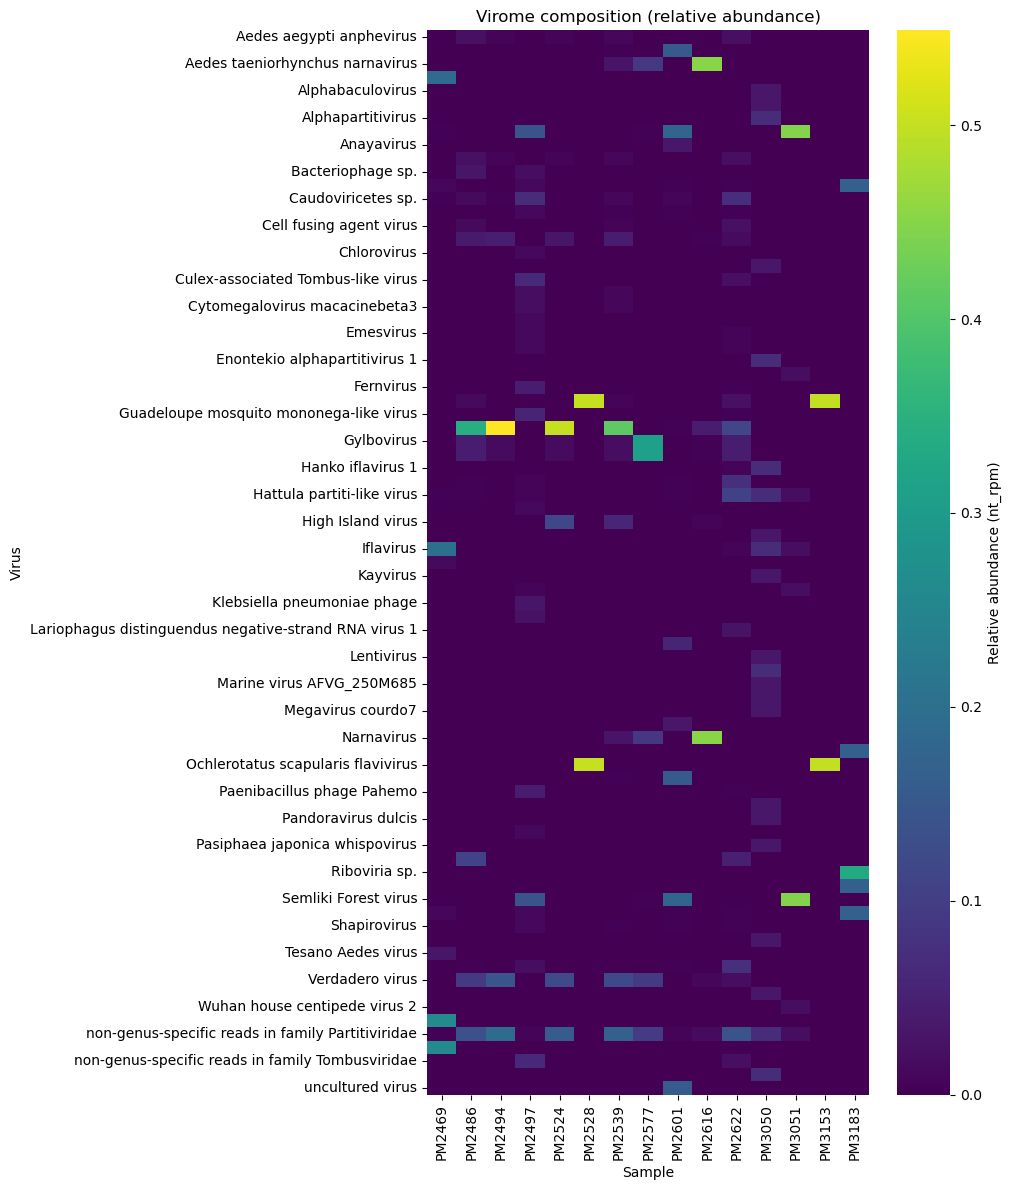

In [10]:
# Data visualization.

pivot = df_final.pivot_table(
    index="name",
    columns="sample_name", 
    values="nt_rpm",
    aggfunc="sum",
    fill_value=0
)
pivot_rel = pivot.div(pivot.sum(axis=0), axis=1)

# Low informative taxa filtering. We filter out taxa that have a relative abundance of less than 1% in all samples.
pivot_filt = pivot_rel[pivot_rel.max(axis=1) > 0.01]  # >1%

plt.figure(figsize=(10, 12))

sns.heatmap(
    pivot_filt,
    cmap="viridis",
    cbar_kws={"label": "Relative abundance (nt_rpm)"}
)

plt.title("Virome composition (relative abundance)")
plt.xlabel("Sample")
plt.ylabel("Virus")
plt.tight_layout()
plt.show()

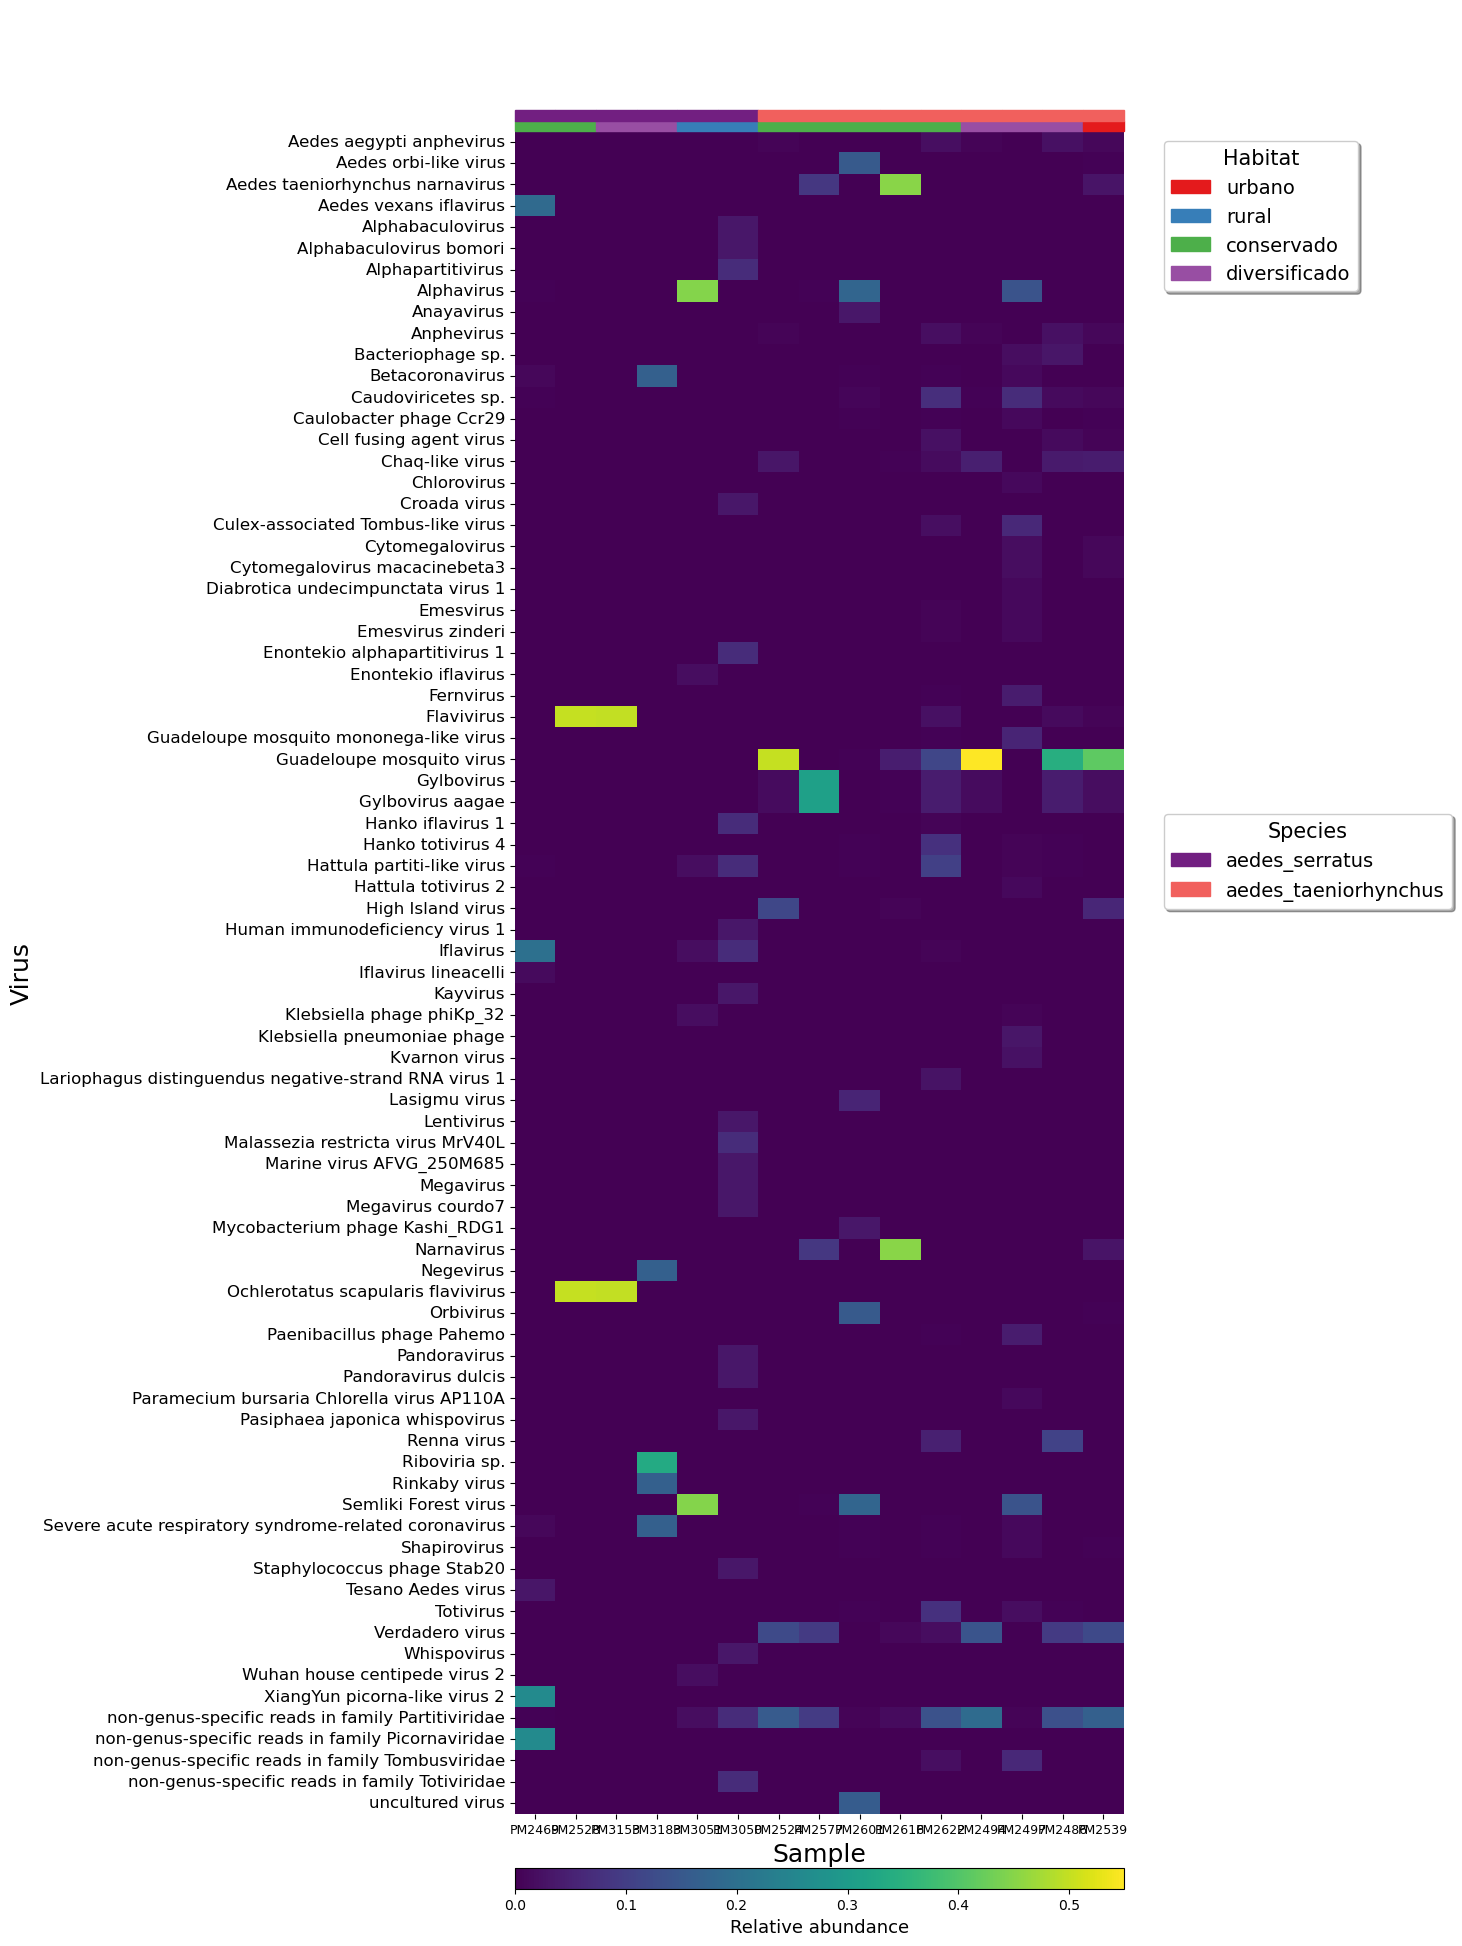

In [ ]:
order = df_metadata.sort_values(["species", "habitat"])["sample_name"]

# Only those samples that remain after filtering
order = [s for s in order if s in pivot_filt.columns]

pivot_ordered = pivot_filt[order]

# Index metadata
meta = df_metadata.set_index("sample_name")

# Colors mapping (same as before)
habitat_colors = meta.loc[order, "habitat"].map({
    "urbano": "#e41a1c",
    "rural": "#377eb8",
    "conservado": "#4daf4a",
    "diversificado": "#984ea3"
})

species_unique = meta["species"].unique()
palette = sns.color_palette("magma", len(species_unique))
species_color_dict = dict(zip(species_unique, palette))
species_colors = meta.loc[order, "species"].map(species_color_dict)

# Subplots for title and heatmap
fig, (ax_title, ax_heatmap) = plt.subplots(
    2, 1, 
    figsize=(15, 20), 
    gridspec_kw={'height_ratios': [0.5, 10]}
)

# Subplot for title hidden 
ax_title.axis('off')
ax_title.set_title("Virome composition by habitat and species", fontsize=20, pad=1)

# Create heatmap without colorbar first
ax = sns.heatmap(
    pivot_ordered,
    cmap="viridis",
    cbar=False,  
    ax=ax_heatmap,
    xticklabels=True,
    yticklabels=True
)

# y-axis tick labels font size
ax.tick_params(axis='y', labelsize=12)  # Adjust size as needed 
ax.tick_params(axis='x', labelsize=9)  # Sample names font size

# Add colorbar at the bottom
cbar = fig.colorbar(ax.collections[0], ax=ax, orientation='horizontal', 
                    pad=0.03, fraction=0.05, aspect=30)
cbar.set_label("Relative abundance", fontsize=13)

# Habitat color above heatmap
for i, color in enumerate(habitat_colors):
    ax.add_patch(
        plt.Rectangle((i, -0.5), 1, 0.5, color=color, transform=ax.transData, clip_on=False)
    )

# Species color above habitat
for i, color in enumerate(species_colors):
    ax.add_patch(
        plt.Rectangle((i, -1.0), 1, 0.5, color=color, transform=ax.transData, clip_on=False)
    )

# Habitat Leyend
hab_legend = [
    mpatches.Patch(color=color, label=hab)
    for hab, color in {
        "urbano": "#e41a1c",
        "rural": "#377eb8",
        "conservado": "#4daf4a",
        "diversificado": "#984ea3"
    }.items()
]

# Species Leyend
sp_legend = [
    mpatches.Patch(color=color, label=sp)
    for sp, color in species_color_dict.items()
]

# Add both legends on the right side without overlap
legend1 = ax.legend(
    handles=hab_legend,
    title="Habitat",
    bbox_to_anchor=(1.05, 1.0),
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=14,
    title_fontsize=15
)

legend2 = ax.legend(
    handles=sp_legend,
    title="Species",
    bbox_to_anchor=(1.05, 0.6),
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=14,
    title_fontsize=15
)

ax.add_artist(legend1)

# Etiquetas de ejes
ax.set_xlabel("Sample", fontsize=18)
ax.set_ylabel("Virus", fontsize=18)

plt.tight_layout()

# Full path
output_path = base_path / 'results' / 'czid' / 'ViromeCompositionHeatmap.png'

plt.savefig(
    output_path, 
    dpi=300,                    # Resolution
    bbox_inches='tight',        # Removes extra white space
    format='png',               # Format
    transparent=False,          # Set to True for transparent background
    facecolor='white'           # Background color
)

plt.show()

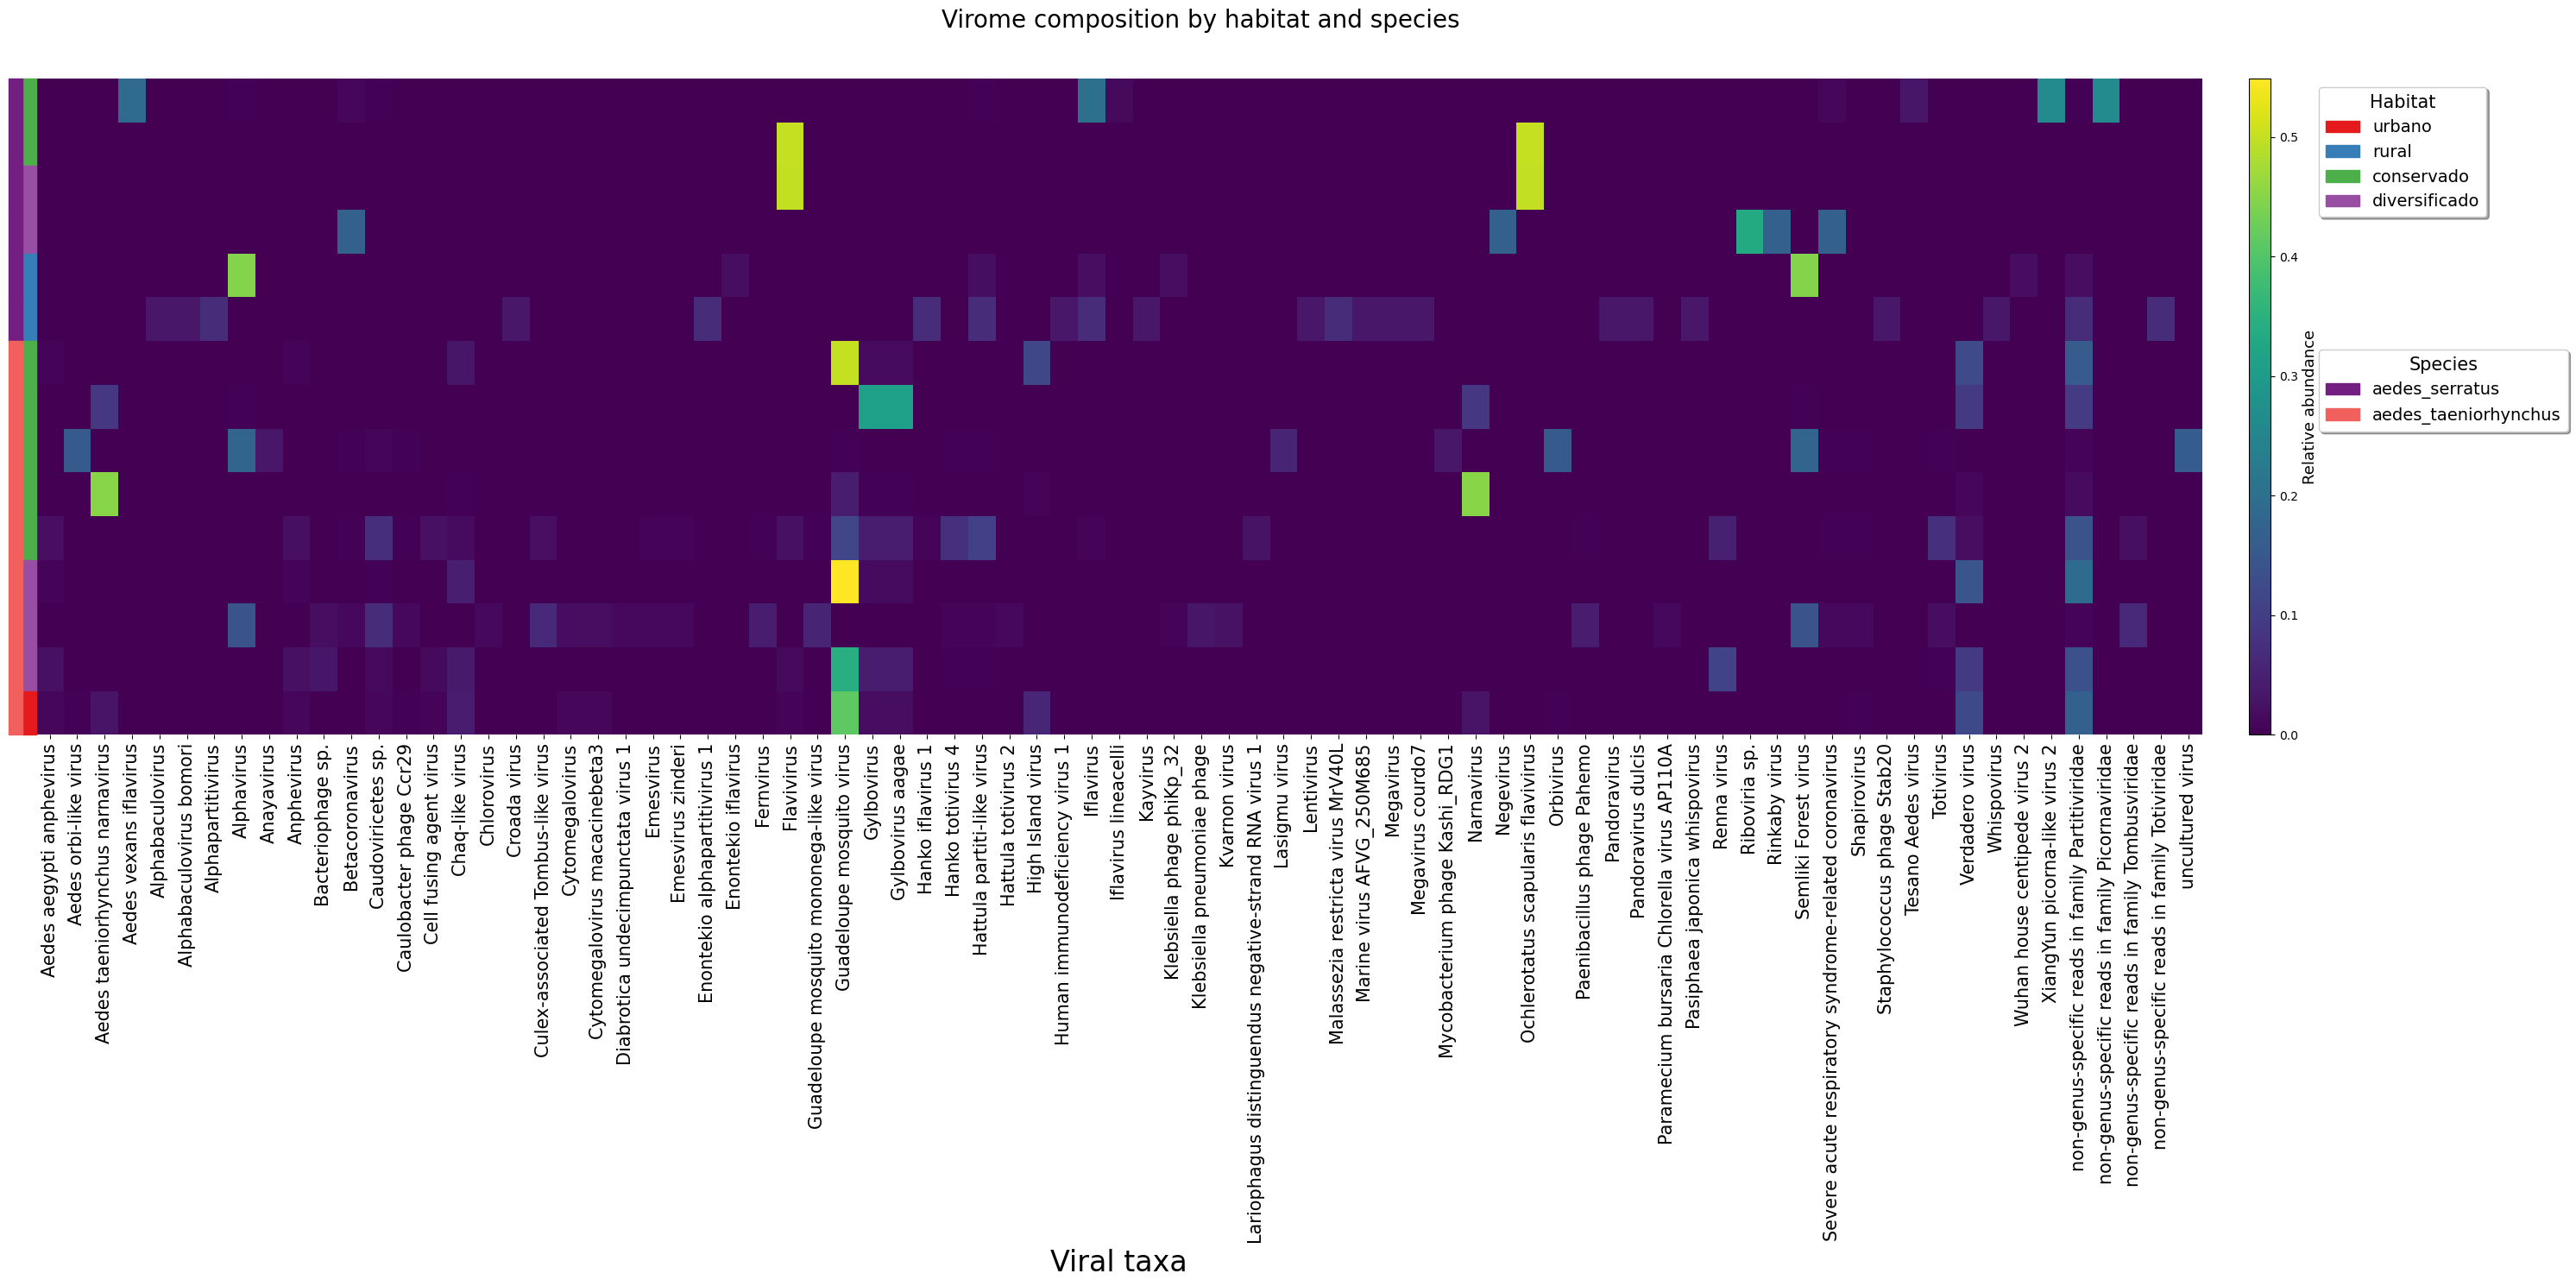

In [25]:
order = df_metadata.sort_values(["species", "habitat"])["sample_name"]

# Only those samples that remain after filtering
order = [s for s in order if s in pivot_filt.columns]

pivot_ordered = pivot_filt[order]

pivot_transposed = pivot_ordered.T

# Index metadata
meta = df_metadata.set_index("sample_name")

# Colors mapping (same as before)
habitat_colors = meta.loc[order, "habitat"].map({
    "urbano": "#e41a1c",
    "rural": "#377eb8",
    "conservado": "#4daf4a",
    "diversificado": "#984ea3"
})

species_unique = meta["species"].unique()
palette = sns.color_palette("magma", len(species_unique))
species_color_dict = dict(zip(species_unique, palette))
species_colors = meta.loc[order, "species"].map(species_color_dict)

# Subplots for title and heatmap
fig, (ax_title, ax_heatmap) = plt.subplots(
    2, 1, 
    figsize=(30, 15),  
    gridspec_kw={'height_ratios': [0.5, 10]}
)

# Subplot for title hidden 
ax_title.axis('off')
ax_title.set_title("Virome composition by habitat and species", fontsize=20, pad=1)

# Create heatmap without colorbar first
ax = sns.heatmap(
    pivot_transposed,
    cmap="viridis",
    cbar=False,  
    ax=ax_heatmap,
    xticklabels=True,
    yticklabels=False
)

# y-axis tick labels font size
ax.tick_params(axis='y', labelsize=12)  
ax.tick_params(axis='x', labelsize=15)  

# Add colorbar at the bottom
cbar = fig.colorbar(ax.collections[0], ax=ax, orientation='vertical',  
                    pad=0.02, fraction=0.05, aspect=30)
cbar.set_label("Relative abundance", fontsize=13)

# Habitat color above heatmap
for i, color in enumerate(habitat_colors):
    ax.add_patch(
        plt.Rectangle((-0.5, i), 0.5, 1, color=color, transform=ax.transData, clip_on=False)
    )

# Species color above habitat
for i, color in enumerate(species_colors):
    ax.add_patch(
        plt.Rectangle((-1.0, i), 0.5, 1, color=color, transform=ax.transData, clip_on=False)
    )

# Habitat Leyend
hab_legend = [
    mpatches.Patch(color=color, label=hab)
    for hab, color in {
        "urbano": "#e41a1c",
        "rural": "#377eb8",
        "conservado": "#4daf4a",
        "diversificado": "#984ea3"
    }.items()
]

# Species Leyend
sp_legend = [
    mpatches.Patch(color=color, label=sp)
    for sp, color in species_color_dict.items()
]

# Add both legends on the right side without overlap
legend1 = ax.legend(
    handles=hab_legend,
    title="Habitat",
    bbox_to_anchor=(1.05, 1.0),
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=14,
    title_fontsize=15
)

legend2 = ax.legend(
    handles=sp_legend,
    title="Species",
    bbox_to_anchor=(1.05, 0.6),
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=14,
    title_fontsize=15
)

ax.add_artist(legend1)

# Etiquetas de ejes
ax.set_xlabel("Viral taxa", fontsize=24) 
ax.set_ylabel("", fontsize=18)  

plt.tight_layout()

# Full path
output_path = base_path / 'results' / 'czid' / 'ViromeCompositionHeatmap2.png'

plt.savefig(
    output_path, 
    dpi=300,                    # Resolution
    bbox_inches='tight',        # Removes extra white space
    format='png',               # Format
    transparent=False,          # Set to True for transparent background
    facecolor='white'           # Background color
)

plt.show()

### PCA Analysis.

PC1 explains: 25.85%
PC2 explains: 15.81%
Total explained: 41.66%


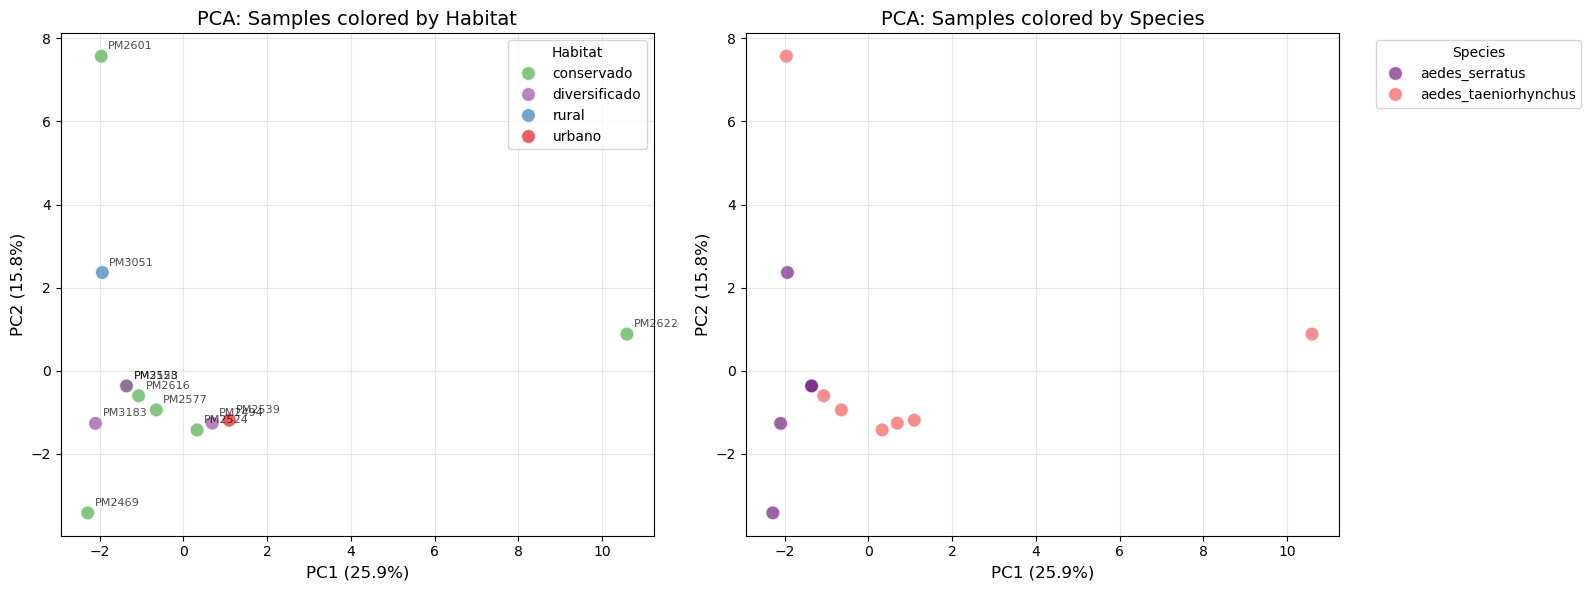


Explained variance ratio:
PC1: 25.85% (cumulative: 25.85%)
PC2: 15.81% (cumulative: 41.66%)
PC3: 14.61% (cumulative: 56.27%)
PC4: 12.66% (cumulative: 68.93%)
PC5: 11.41% (cumulative: 80.33%)


In [14]:
# pivot_ordered: rows = viruses, columns = samples

# Transpose so samples are rows and viruses are columns
pca_data = pivot_ordered.T  # Now: samples as rows, viruses as columns

# Replace NaN values with 0 (if any)
pca_data = pca_data.fillna(0)

# Standardize the data
scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)

# Perform PCA
pca = PCA(n_components=10)  # Calculate 10 components initially
pca_result = pca.fit_transform(pca_data_scaled)

# Create DataFrame with PCA results
pca_df = pd.DataFrame(
    pca_result[:, :5],  # First 5 components
    columns=[f'PC{i+1}' for i in range(5)],
    index=pca_data.index
)

# Add metadata
pca_df['habitat'] = meta.loc[pca_df.index, 'habitat']
pca_df['species'] = meta.loc[pca_df.index, 'species']
pca_df['sample_name'] = pca_df.index

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print(f"PC1 explains: {explained_variance[0]:.2%}")
print(f"PC2 explains: {explained_variance[1]:.2%}")
print(f"Total explained: {explained_variance[:2].sum():.2%}")

# Create PCA plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Colored by habitat
scatter1 = sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', 
    hue='habitat', palette={
        "urbano": "#e41a1c",
        "rural": "#377eb8",
        "conservado": "#4daf4a",
        "diversificado": "#984ea3"},
    s=100, alpha=0.7, ax=ax1
)
ax1.set_xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=12)
ax1.set_ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=12)
ax1.set_title('PCA: Samples colored by Habitat', fontsize=14)
ax1.legend(title='Habitat')
ax1.grid(True, alpha=0.3)

# Add sample labels
for idx, row in pca_df.iterrows():
    ax1.annotate(row['sample_name'], (row['PC1'], row['PC2']), 
                 fontsize=8, alpha=0.7, xytext=(5, 5), 
                 textcoords='offset points')

# Plot 2: Colored by species
scatter2 = sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', 
    hue='species', palette='magma',
    s=100, alpha=0.7, ax=ax2
)
ax2.set_xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=12)
ax2.set_ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=12)
ax2.set_title('PCA: Samples colored by Species', fontsize=14)
ax2.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print variance explained by each component
print("\nExplained variance ratio:")
for i, var in enumerate(explained_variance[:5]):
    print(f"PC{i+1}: {var:.2%} (cumulative: {explained_variance[:i+1].sum():.2%})")

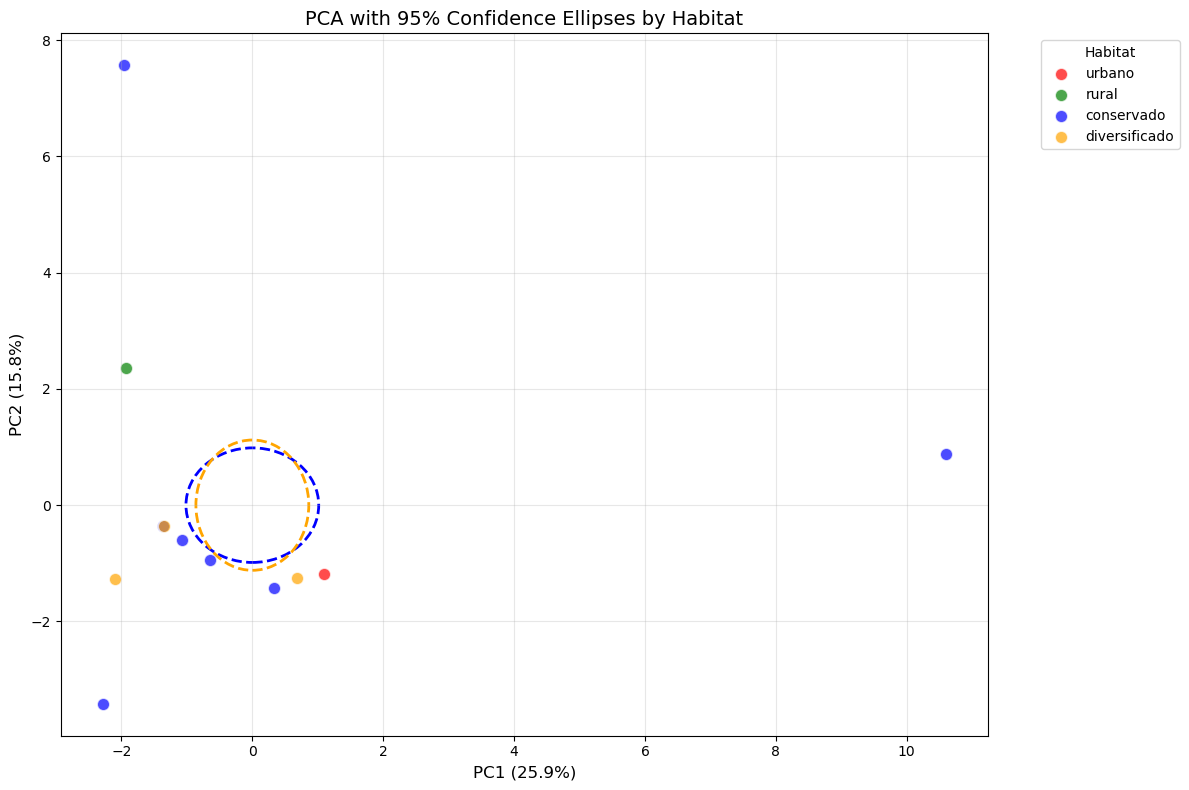

In [15]:
from scipy.stats import chi2

# Define habitat_color_map (match with your actual habitat values)
habitat_color_map = {
    "urbano": "red",
    "rural": "green",
    "conservado": "blue",
    "diversificado": "orange"
}

# Also define species color map if needed
species_color_map = dict(zip(species_unique, sns.color_palette("tab10", len(species_unique))))

def confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):
    """Create confidence ellipse"""
    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = plt.gca().transData
    ellipse.set_transform(transf)
    return ax.add_patch(ellipse)

from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(12, 8))

# Plot with ellipses for each habitat
for habitat, color in habitat_color_map.items():
    habitat_data = pca_df[pca_df['habitat'] == habitat]
    ax.scatter(habitat_data['PC1'], habitat_data['PC2'], 
              c=color, label=habitat, s=80, alpha=0.7, edgecolors='white')
    
    # Add confidence ellipse (95% confidence)
    if len(habitat_data) > 2:  # Need at least 3 points for ellipse
        confidence_ellipse(habitat_data['PC1'], habitat_data['PC2'], ax,
                          n_std=2.0, edgecolor=color, facecolor='none', 
                          linewidth=2, linestyle='--')

ax.set_xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=12)
ax.set_title('PCA with 95% Confidence Ellipses by Habitat', fontsize=14)
ax.legend(title='Habitat', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

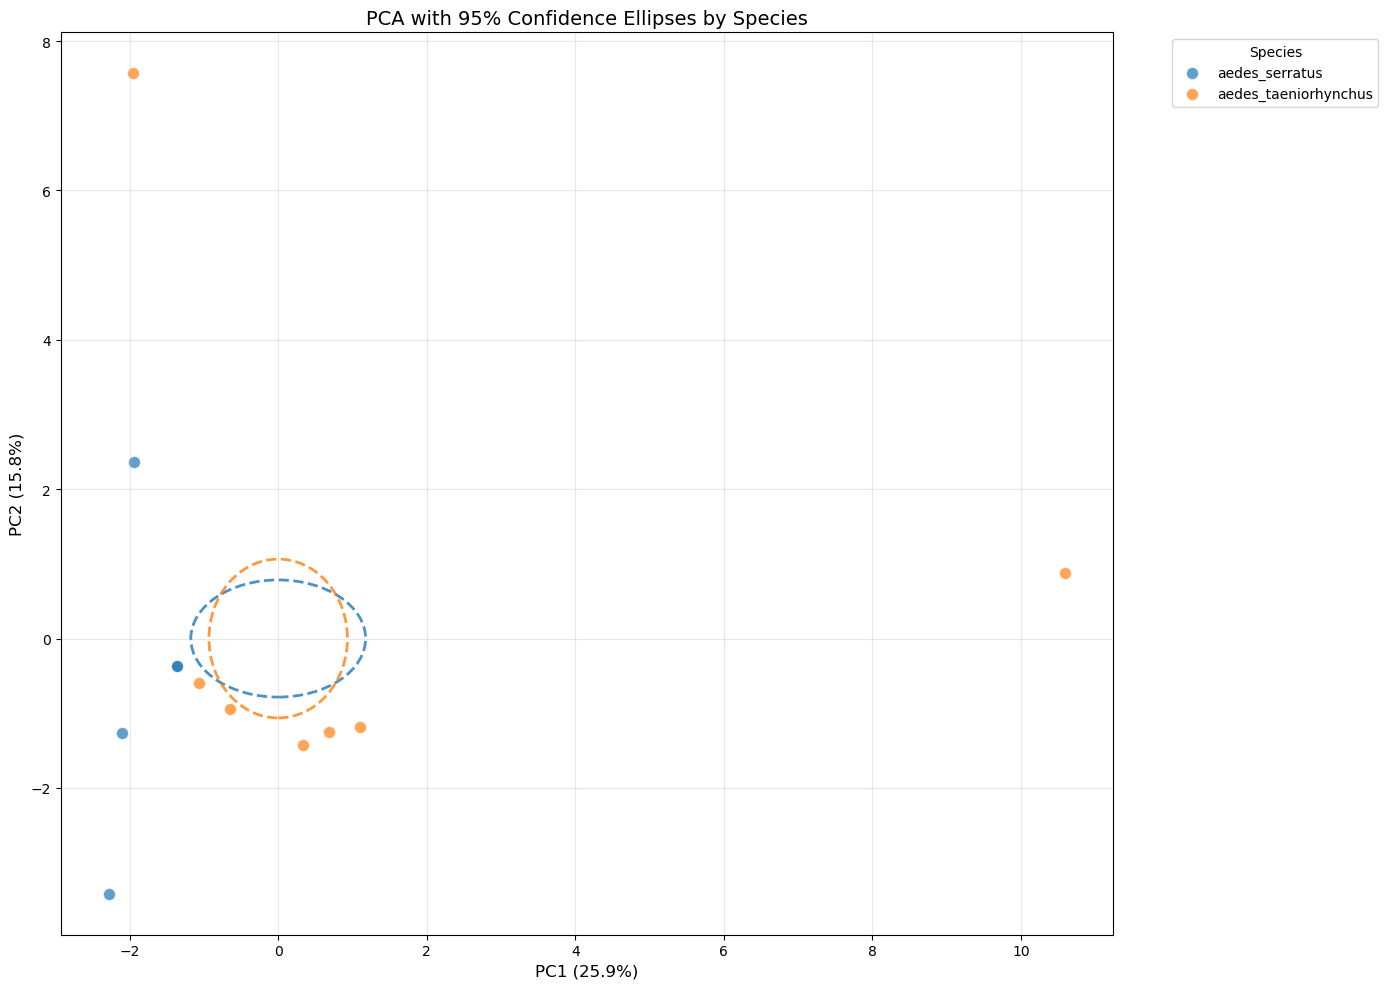

In [16]:
# Plot with ellipses for each species
fig, ax = plt.subplots(figsize=(14, 10))

# Get unique species
unique_species = pca_df['species'].unique()
species_colors = sns.color_palette("tab10", len(unique_species))
species_color_map = dict(zip(unique_species, species_colors))

# Plot with ellipses for each species
for species, color in species_color_map.items():
    species_data = pca_df[pca_df['species'] == species]
    
    if len(species_data) > 0:
        ax.scatter(species_data['PC1'], species_data['PC2'], 
                  c=[color], label=species, s=80, alpha=0.7, edgecolors='white', linewidth=1)
        
        # Add confidence ellipse (95% confidence)
        if len(species_data) >= 3:
            confidence_ellipse(species_data['PC1'], species_data['PC2'], ax,
                              n_std=2.0, edgecolor=color, facecolor='none', 
                              linewidth=2, linestyle='--', alpha=0.8)

ax.set_xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=12)
ax.set_title('PCA with 95% Confidence Ellipses by Species', fontsize=14)
ax.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

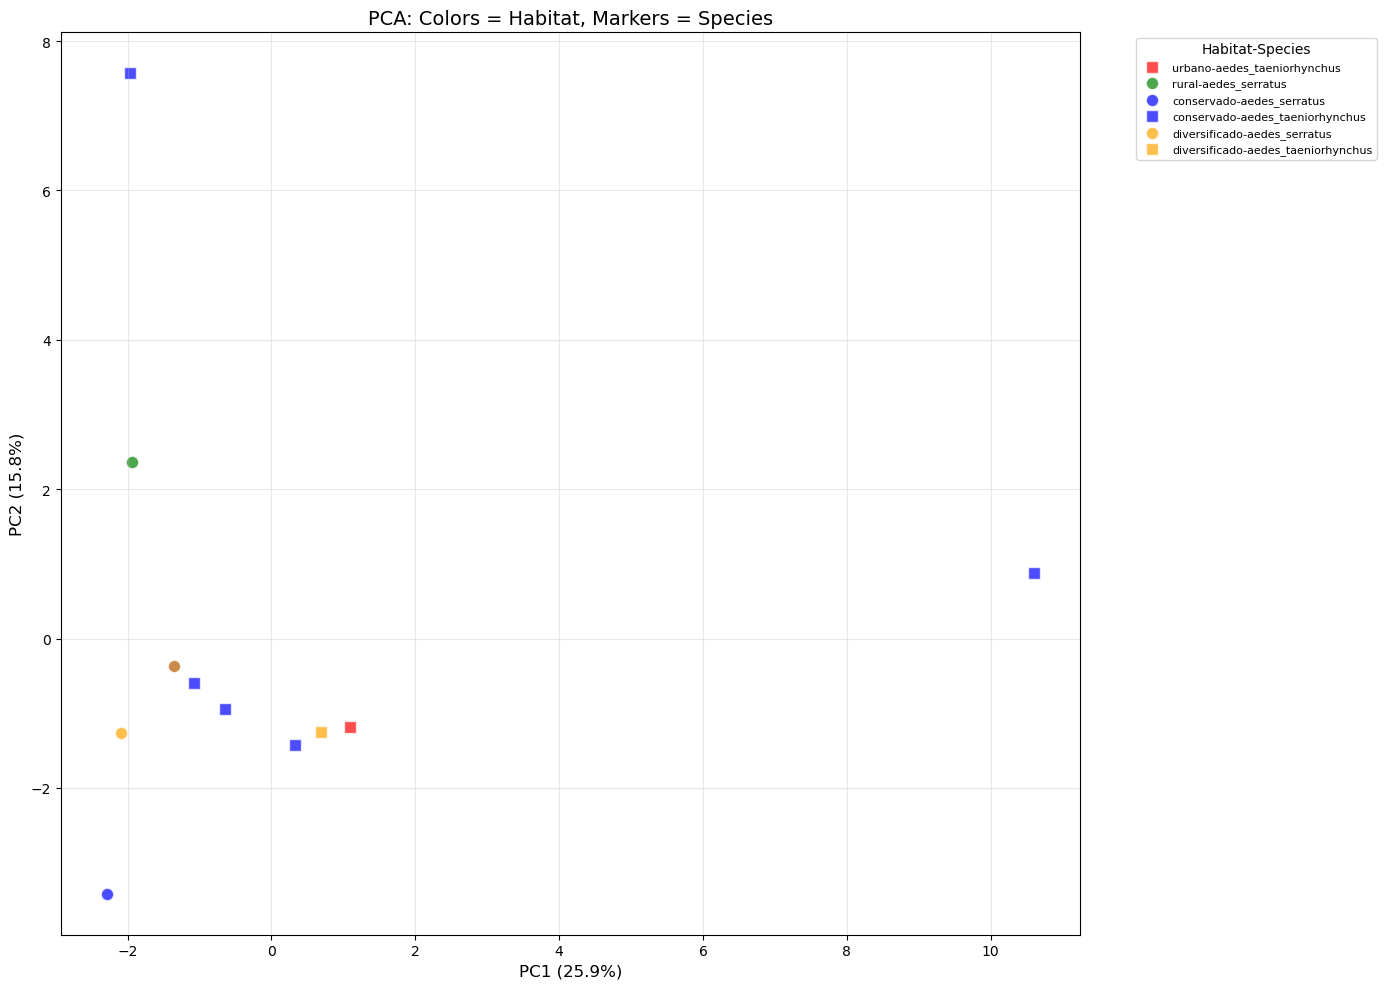

In [17]:
# Combined plot with different markers for species and colors for habitats
fig, ax = plt.subplots(figsize=(14, 10))

# Define marker styles for species
species_markers = {species: marker for species, marker in zip(unique_species, ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h'])}

# Plot with colors for habitats and markers for species
for habitat, color in habitat_color_map.items():
    habitat_data = pca_df[pca_df['habitat'] == habitat]
    
    for species in habitat_data['species'].unique():
        species_data = habitat_data[habitat_data['species'] == species]
        if len(species_data) > 0:
            ax.scatter(species_data['PC1'], species_data['PC2'], 
                      c=color, label=f"{habitat}-{species}", s=80, alpha=0.7, 
                      marker=species_markers.get(species, 'o'), edgecolors='white', linewidth=1)

ax.set_xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=12)
ax.set_title('PCA: Colors = Habitat, Markers = Species', fontsize=14)
ax.legend(title='Habitat-Species', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Total read depth by sample.

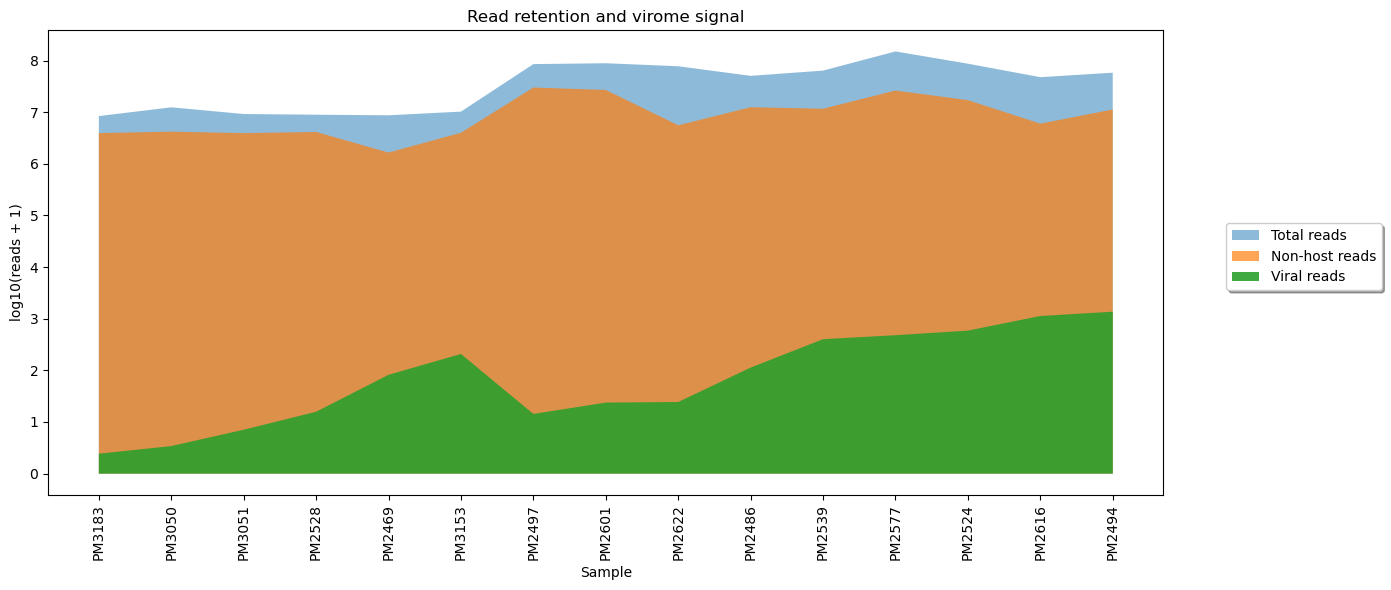

In [19]:
# Read retention and virome signal plot.

# Read definitions:
# Total reads: total number of reads in the sample before any filtering.
# Non-host reads: number of reads that remain after filtering out host reads (mosquito reads in this case).
# Viral reads: number of reads that are classified as viral by CZID.


total_reads = df_metadata.set_index("sample_name")["total_reads"] 

viral_reads = df_final.groupby("sample_name")["nt_rpm"].sum() 

non_host_reads = df_metadata.set_index("sample_name")[ "reads_after_hisat2_host_filtered" ]

df_plot = df_metadata.set_index("sample_name").copy()

# Columnn creation for plotting:
df_plot["viral_reads"] = viral_reads
df_plot["viral_reads"] = df_plot["viral_reads"].fillna(0)
df_plot["non_host_reads"] = df_plot["reads_after_hisat2_host_filtered"]

df_plot["total_log"] = np.log10(df_plot["total_reads"] + 1)
df_plot["non_host_log"] = np.log10(df_plot["non_host_reads"] + 1)
df_plot["viral_log"] = np.log10(df_plot["viral_reads"] + 1)

df_plot["species"] = df_metadata.set_index("sample_name")["species"]

# Order by total reads.
df_plot = df_plot.sort_values(["species", "viral_reads"], ascending=[True, True])

# Plotting
plt.figure(figsize=(14, 6))

x = range(len(df_plot))

plt.fill_between(x, df_plot["total_log"], label="Total reads", alpha=0.5)
plt.fill_between(x, df_plot["non_host_log"], label="Non-host reads", alpha=0.7)
plt.fill_between(x, df_plot["viral_log"], label="Viral reads", alpha=0.9)

plt.xticks(x, df_plot.index, rotation=90)
plt.ylabel("log10(reads + 1)")
plt.xlabel("Sample")
plt.title("Read retention and virome signal")

plt.legend(    
    bbox_to_anchor=(1.05, 0.6),
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
    )
plt.tight_layout()

# Full path
output_path = base_path / 'results' / 'czid' / 'ReadRetention.png'

plt.savefig(
    output_path, 
    dpi=300,                    # Resolution
    bbox_inches='tight',        # Removes extra white space
    format='png',               # Format
    transparent=False,          # Set to True for transparent background
    facecolor='white'           # Background color
)

plt.show()

 

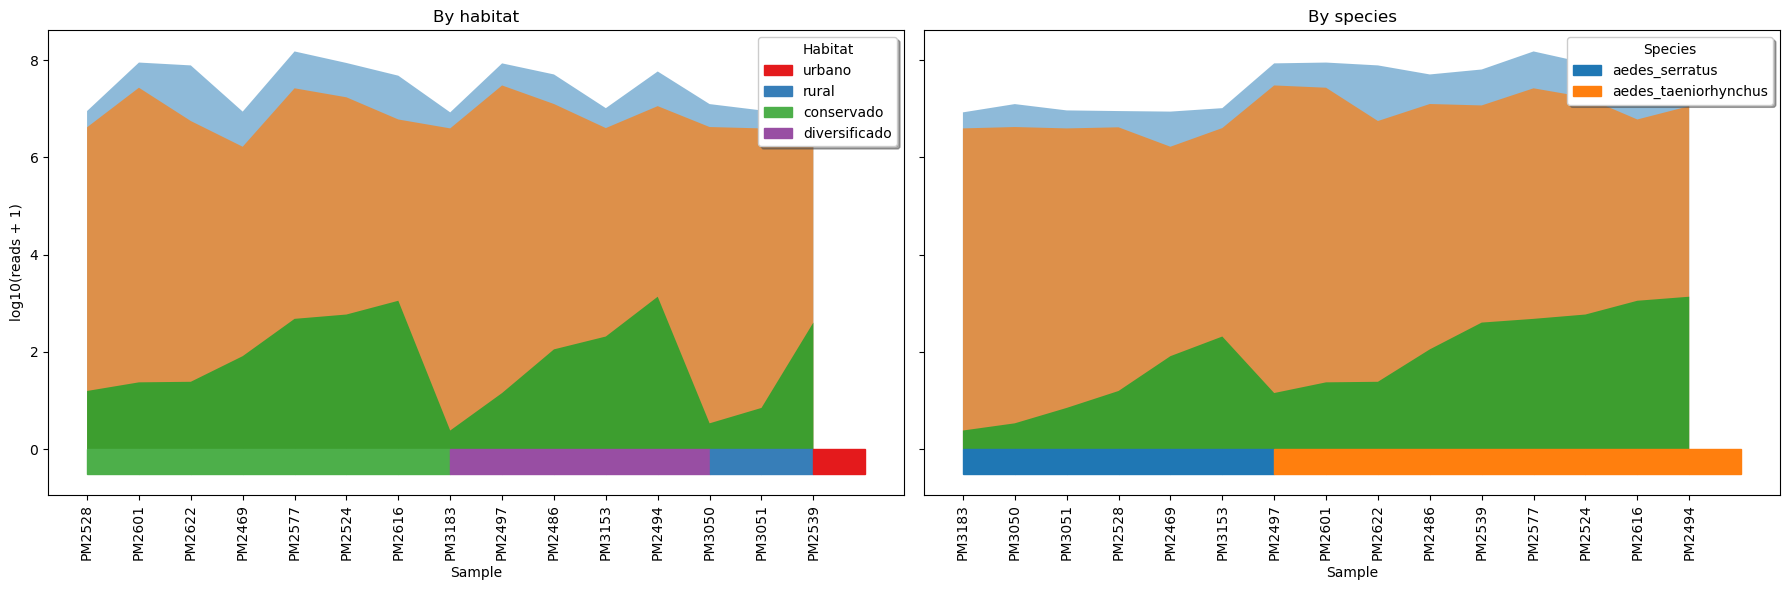

In [13]:
df_plot["species"] = df_metadata.set_index("sample_name")["species"]
df_plot["habitat"] = df_metadata.set_index("sample_name")["habitat"]

# Create two differently sorted dataframes
df_plot_habitat = df_plot.sort_values(["habitat", "viral_reads"], ascending=[True, True])
df_plot_species = df_plot.sort_values(["species", "viral_reads"], ascending=[True, True])

# Create 2 subplots for habitat and species coloring
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

#==============
#   HABITAT
#==============

x1 = range(len(df_plot_habitat))


habitat_colors = df_plot_habitat["habitat"].map({
    "urbano": "#e41a1c",
    "rural": "#377eb8",
    "conservado": "#4daf4a",
    "diversificado": "#984ea3"
})

ax1.fill_between(x1, df_plot_habitat["total_log"], label="Total reads", alpha=0.5)
ax1.fill_between(x1, df_plot_habitat["non_host_log"], label="Non-host reads", alpha=0.7)
ax1.fill_between(x1, df_plot_habitat["viral_log"], label="Viral reads", alpha=0.9)

# Color bars by habitat
for i, c in enumerate(habitat_colors):
    ax1.add_patch(
        plt.Rectangle((i, -0.5), 1, 0.5, color=c, transform=ax1.transData, clip_on=False)
    )

ax1.set_title("By habitat")
ax1.set_xlabel("Sample")
ax1.set_ylabel("log10(reads + 1)")
ax1.set_xticks(x1)
ax1.set_xticklabels(df_plot_habitat.index, rotation=90)

#==============
#   SPECIES
#==============

x2 = range(len(df_plot_species))

species_unique = df_plot_species["species"].unique()
palette = sns.color_palette("tab10", len(species_unique))
species_dict = dict(zip(species_unique, palette))

colors_species = df_plot_species["species"].map(species_dict)

ax2.fill_between(x2, df_plot_species["total_log"], label="Total reads", alpha=0.5)
ax2.fill_between(x2, df_plot_species["non_host_log"], label="Non-host reads", alpha=0.7)
ax2.fill_between(x2, df_plot_species["viral_log"], label="Viral reads", alpha=0.9)

# Color bars by species
for i, c in enumerate(colors_species):
    ax2.add_patch(
        plt.Rectangle((i, -0.5), 1, 0.5, color=c, transform=ax2.transData, clip_on=False)
    )

ax2.set_title("By species")
ax2.set_xlabel("Sample")
ax2.set_xticks(x)
ax2.set_xticklabels(df_plot_species.index, rotation=90)

#==============
#   LEGENDS
#==============

hab_legend = [
    mpatches.Patch(color=color, label=hab)
    for hab, color in {
        "urbano": "#e41a1c",
        "rural": "#377eb8",
        "conservado": "#4daf4a",
        "diversificado": "#984ea3"
    }.items()
]

sp_legend = [
    mpatches.Patch(color=color, label=sp)
    for sp, color in species_dict.items()
]

ax1.legend(
    handles=hab_legend, 
    title="Habitat", 
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
)

ax2.legend(
    handles=sp_legend, 
    title="Species",
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
)

#==============
#   LAYOUT
#==============

plt.tight_layout()

# Full path
output_path = base_path / 'results' / 'czid' / 'ReadRetention_ByHabitat_and_BySpecies.png'

plt.savefig(
    output_path, 
    dpi=300,                    # Resolution
    bbox_inches='tight',        # Removes extra white space
    format='png',               # Format
    transparent=False,          # Set to True for transparent background
    facecolor='white'           # Background color
)


plt.show()

### Viral family read relative abundance by sample.

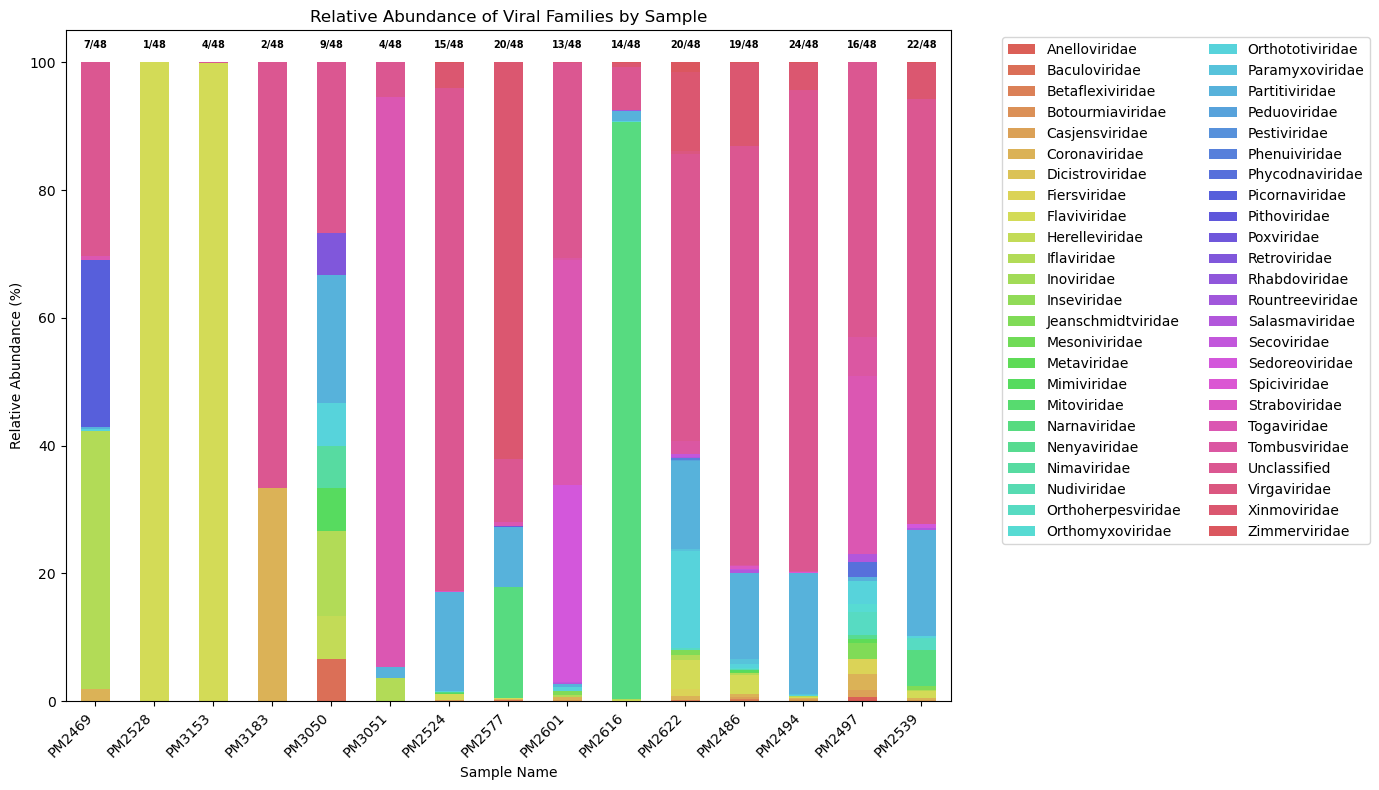

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group and prepare data
df_family_sum = df_final.groupby(['family', 'sample_name'])['nt_rpm'].sum().reset_index()
df_family_sum['relative_abundance'] = df_family_sum.groupby('sample_name')['nt_rpm'].transform(lambda x: x / x.sum() * 100)
df_family_sum = df_family_sum[df_family_sum['relative_abundance'] > 0.01]
pivot_df = df_family_sum.pivot(index='sample_name', columns='family', values='relative_abundance').fillna(0)

# Store family columns BEFORE adding metadata
family_columns = pivot_df.columns.tolist()  # <-- Get family columns first

# Then add metadata
pivot_df['species'] = df_metadata.set_index('sample_name')['species']
pivot_df['habitat'] = df_metadata.set_index('sample_name')['habitat']

# Sort by species
pivot_df = pivot_df.sort_values(['species', 'habitat'], ascending=[True, True])

# Generate unique colors for families only
unique_families = family_columns  # <-- Use saved family columns, not all columns
num_families = len(unique_families)

# Create a color palette with enough distinct colors
if num_families <= 10:
    palette = sns.color_palette("tab10", num_families)
elif num_families <= 20:
    palette = sns.color_palette("tab20", num_families)
elif num_families <= 30:
    palette = sns.color_palette("Set3", num_families)
else:
    palette = sns.color_palette("hls", num_families)

color_dict = dict(zip(unique_families, palette))

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot only the family columns (excluding species and habitat)
pivot_df[unique_families].plot(kind='bar', stacked=True, 
                                color=[color_dict[col] for col in unique_families], 
                                ax=ax)

# Calculate metrics per sample (using only family columns)
total_families = len(unique_families)
family_counts = (pivot_df[unique_families] > 0).sum(axis=1)
family_percentages = (family_counts / total_families * 100).round(1)

# Add combined labels above bars
for i, (idx, count) in enumerate(family_counts.items()):
    # Get total height of the bar (should be ~100)
    total_height = pivot_df[unique_families].iloc[i].sum()
    ax.text(i, total_height + 2, f'{count}/{total_families}', 
            ha='center', va='bottom', fontsize=7, 
            fontweight='bold', linespacing=1.2)

plt.title('Relative Abundance of Viral Families by Sample')
plt.xlabel('Sample Name')
plt.ylabel('Relative Abundance (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

plt.tight_layout()

# Full path
output_path = base_path / 'results' / 'czid' / 'ViralFamilyRelativeAbundance.png'

plt.savefig(
    output_path, 
    dpi=300,
    bbox_inches='tight',
    format='png',
    transparent=False,
    facecolor='white'
)

plt.show()

### Viral Diversity

 Matrix created: 15 samples × 484 taxa

 Metrics calculated:
   - Shannon: range [0.69, 3.26]
   - Simpson: range [0.50, 0.95]
   - Richness: range [2, 83]

STATISTICAL TESTS (* p < 0.05, ** p < 0.01, *** p < 0.001)

Shannon by Habitat (Kruskal-Wallis):
  H-statistic: 0.289
  p-value: 0.9620 ns

Simpson by Habitat (Kruskal-Wallis):
  H-statistic: 0.389
  p-value: 0.9424 ns

Richness by Habitat (Kruskal-Wallis):
  H-statistic: 2.854
  p-value: 0.4146 ns

Shannon by Species (Mann-Whitney U):
  U-statistic: 14.000
  p-value: 0.1447 ns

Simpson by Species (Mann-Whitney U):
  U-statistic: 19.000
  p-value: 0.3884 ns

Richness by Species (Mann-Whitney U):
  U-statistic: 0.000
  p-value: 0.0004 ***


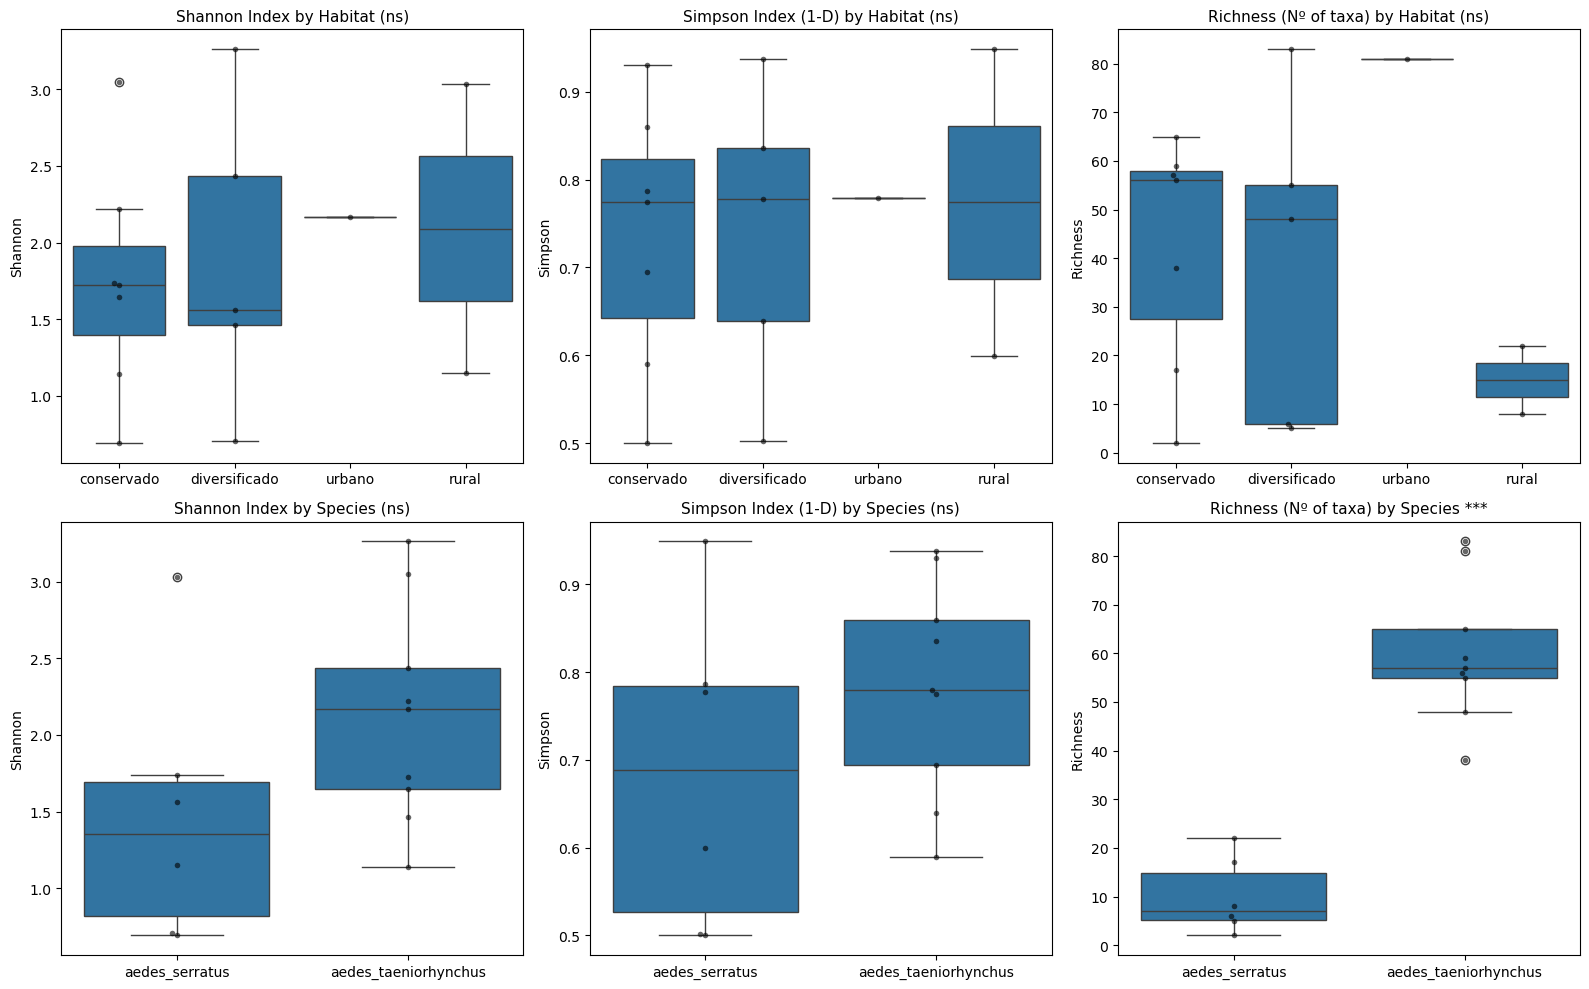


RESULTS BY SAMPLE (sorted by Shannon)
sample_name       habitat              species  Richness  Shannon  Simpson
     PM2497 diversificado aedes_taeniorhynchus        48    3.262    0.938
     PM2622    conservado aedes_taeniorhynchus        56    3.047    0.930
     PM3050         rural       aedes_serratus        22    3.032    0.949
     PM2486 diversificado aedes_taeniorhynchus        55    2.437    0.836
     PM2601    conservado aedes_taeniorhynchus        38    2.221    0.860
     PM2539        urbano aedes_taeniorhynchus        81    2.167    0.779
     PM2469    conservado       aedes_serratus        17    1.738    0.787
     PM2577    conservado aedes_taeniorhynchus        59    1.724    0.775
     PM2524    conservado aedes_taeniorhynchus        57    1.647    0.695
     PM3183 diversificado       aedes_serratus         5    1.561    0.778
     PM2494 diversificado aedes_taeniorhynchus        83    1.465    0.640
     PM3051         rural       aedes_serratus         8    1

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# =============================================
# FUNCTION TO CALCULATE SHANNON MANUALLY
# =============================================
def calculate_shannon(abundance_df):
    """
    Calculates Shannon diversity index for each sample.
    Formula: H = -Σ(p_i * ln(p_i))
    """
    mat = abundance_df.values
    row_sums = mat.sum(axis=1, keepdims=True)
    
    # Calculate proportions, avoiding division by zero
    proportions = np.divide(mat, row_sums, 
                            out=np.zeros_like(mat, dtype=float), 
                            where=row_sums!=0)
    
    # Calculate natural log, handling log(0) = 0
    with np.errstate(divide='ignore', invalid='ignore'):
        log_p = np.where(proportions > 0, np.log(proportions), 0)
    
    shannon = -np.sum(proportions * log_p, axis=1)
    return pd.Series(shannon, index=abundance_df.index)


def calculate_simpson(abundance_df):
    """
    Calculates Simpson diversity index (1-D) for each sample.
    Formula: D = Σ(p_i²) -> 1-D (diversity)
    """
    mat = abundance_df.values
    row_sums = mat.sum(axis=1, keepdims=True)
    
    proportions = np.divide(mat, row_sums, 
                            out=np.zeros_like(mat, dtype=float), 
                            where=row_sums!=0)
    
    # Simpson's dominance (D)
    D = np.sum(proportions**2, axis=1)
    # Simpson's diversity index (1-D)
    simpson = 1 - D
    
    return pd.Series(simpson, index=abundance_df.index)


# =============================================
# ABUNDANCE MATRIX
# =============================================
pivot_abundance = df_final.pivot_table(
    index='sample_name', 
    columns='name', 
    values='nt_rpm', 
    aggfunc='sum', 
    fill_value=0
)

print(f" Matrix created: {pivot_abundance.shape[0]} samples × {pivot_abundance.shape[1]} taxa")


# =============================================
# DIVERSITY METRICS
# =============================================
shannon_values = calculate_shannon(pivot_abundance)
simpson_values = calculate_simpson(pivot_abundance)
richness_values = (pivot_abundance > 0).sum(axis=1)

# Create DataFrame with all results
diversity_df = pd.DataFrame({
    'Shannon': shannon_values,
    'Simpson': simpson_values,
    'Richness': richness_values
})

# Merge with metadata
diversity_df = diversity_df.merge(df_metadata, left_index=True, right_on='sample_name')

print("\n Metrics calculated:")
print(f"   - Shannon: range [{diversity_df['Shannon'].min():.2f}, {diversity_df['Shannon'].max():.2f}]")
print(f"   - Simpson: range [{diversity_df['Simpson'].min():.2f}, {diversity_df['Simpson'].max():.2f}]")
print(f"   - Richness: range [{diversity_df['Richness'].min()}, {diversity_df['Richness'].max()}]")


# =============================================
# 3. STATISTICAL TESTS (with significance markers)
# =============================================
print("\n" + "="*60)
print("STATISTICAL TESTS (* p < 0.05, ** p < 0.01, *** p < 0.001)")
print("="*60)

# Store p-values for later use in plot titles
habitat_pvalues = {}
species_pvalues = {}

# Group by habitat
habitats = diversity_df['habitat'].unique()
for metric in ['Shannon', 'Simpson', 'Richness']:
    groups = [diversity_df[diversity_df['habitat'] == h][metric].values for h in habitats]
    h_stat, p_value = stats.kruskal(*groups)
    habitat_pvalues[metric] = p_value
    
    # Determine significance marker
    if p_value < 0.001:
        sig_marker = "***"
    elif p_value < 0.01:
        sig_marker = "**"
    elif p_value < 0.05:
        sig_marker = "*"
    else:
        sig_marker = "ns"
        
    print(f"\n{metric} by Habitat (Kruskal-Wallis):")
    print(f"  H-statistic: {h_stat:.3f}")
    print(f"  p-value: {p_value:.4f} {sig_marker}")

# Group by species
species_list = diversity_df['species'].unique()
for metric in ['Shannon', 'Simpson', 'Richness']:
    group1 = diversity_df[diversity_df['species'] == species_list[0]][metric].values
    group2 = diversity_df[diversity_df['species'] == species_list[1]][metric].values
    u_stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
    species_pvalues[metric] = p_value
    
    # Determine significance marker
    if p_value < 0.001:
        sig_marker = "***"
    elif p_value < 0.01:
        sig_marker = "**"
    elif p_value < 0.05:
        sig_marker = "*"
    else:
        sig_marker = "ns"
        
    print(f"\n{metric} by Species (Mann-Whitney U):")
    print(f"  U-statistic: {u_stat:.3f}")
    print(f"  p-value: {p_value:.4f} {sig_marker}")


# =============================================
# 4. VISUALIZATION
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = ['Shannon', 'Simpson', 'Richness']
metric_titles = ['Shannon Index', 'Simpson Index (1-D)', 'Richness (Nº of taxa)']

for i, (metric, title) in enumerate(zip(metrics, metric_titles)):
    
    # --- By Habitat (top row) ---
    sns.boxplot(data=diversity_df, x='habitat', y=metric, ax=axes[0, i])
    sns.swarmplot(data=diversity_df, x='habitat', y=metric, ax=axes[0, i], 
                  color='black', size=4, alpha=0.6)
    
    # Add significance marker to title
    p_val = habitat_pvalues[metric]
    if p_val < 0.001:
        sig_str = " ***"
    elif p_val < 0.01:
        sig_str = " **"
    elif p_val < 0.05:
        sig_str = " *"
    else:
        sig_str = " (ns)"
        
    axes[0, i].set_title(f'{title} by Habitat{sig_str}', fontsize=11)
    axes[0, i].set_xlabel('')
    
    # --- By Species (bottom row) ---
    sns.boxplot(data=diversity_df, x='species', y=metric, ax=axes[1, i])
    sns.swarmplot(data=diversity_df, x='species', y=metric, ax=axes[1, i], 
                  color='black', size=4, alpha=0.6)
    
    # Add significance marker to title
    p_val = species_pvalues[metric]
    if p_val < 0.001:
        sig_str = " ***"
    elif p_val < 0.01:
        sig_str = " **"
    elif p_val < 0.05:
        sig_str = " *"
    else:
        sig_str = " (ns)"
        
    axes[1, i].set_title(f'{title} by Species{sig_str}', fontsize=11)
    axes[1, i].set_xlabel('')

plt.tight_layout()

# Full path
output_path = base_path / 'results' / 'czid' / 'ViralTaxaDiversity.png'

plt.savefig(
    output_path, 
    dpi=300,                    # Resolution
    bbox_inches='tight',        # Removes extra white space
    format='png',               # Format
    transparent=False,          # Set to True for transparent background
    facecolor='white'           # Background color
)

plt.show()


# =============================================
# 5. RESULTS TABLE
# =============================================
print("\n" + "="*60)
print("RESULTS BY SAMPLE (sorted by Shannon)")
print("="*60)
result_table = diversity_df[['sample_name', 'habitat', 'species', 'Richness', 'Shannon', 'Simpson']].sort_values('Shannon', ascending=False)
print(result_table.round(3).to_string(index=False))


# =============================================
# 6. SUMMARY BY GROUP
# =============================================
print("\n" + "="*60)
print("SUMMARY BY HABITAT (mean ± standard deviation)")
print("="*60)
habitat_summary = diversity_df.groupby('habitat')[['Richness', 'Shannon', 'Simpson']].agg(['mean', 'std']).round(3)
print(habitat_summary)

print("\n" + "="*60)
print("SUMMARY BY SPECIES (mean ± standard deviation)")
print("="*60)
species_summary = diversity_df.groupby('species')[['Richness', 'Shannon', 'Simpson']].agg(['mean', 'std']).round(3)
print(species_summary)

In [16]:
# csv data for R analysis

# Main dataframe
df_final.to_csv(base_path / 'docs/czid_sequence_reports/processed/df_final.csv', index=False)

# Metadata
df_metadata.to_csv(base_path / 'docs/czid_sequence_reports/processed/metadata.csv', index=False)

# Abundance matrix
pivot_abundance.to_csv(base_path / 'docs/czid_sequence_reports/processed/abundance_matrix.csv')

# Diversity metrics
diversity_df.to_csv(base_path / 'docs/czid_sequence_reports/processed/diversity_metrics.csv', index=False)
